<a href="https://colab.research.google.com/github/nicholas-schwier-class/Stats-Sum-26/blob/main/Class_12_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.multicomp import pairwise_tukeyhsd

from statsmodels.stats.power import FTestAnovaPower

Create Example Data

In [3]:
np.random.seed(42)

lecture = np.random.normal(72, 6, 30)
online = np.random.normal(80, 6, 30)
hybrid = np.random.normal(77, 6, 30)

Build the Data Frame

In [4]:
scores = np.concatenate([lecture,
                         online,
                         hybrid])

group = (["Lecture"]*30 +
         ["Online"]*30 +
         ["Hybrid"]*30)

df = pd.DataFrame({
    "Score": scores,
    "Group": group
})

df.head()

,Score,Group
0,74.980285,Lecture
1,71.170414,Lecture
2,75.886131,Lecture
3,81.138179,Lecture
4,70.595080,Lecture


Descriptive Stats

In [5]:
df.groupby("Group").describe()

Score                                                        \
        count       mean       std        min        25%        50%   
Group                                                                 
Hybrid   30.0  77.077309  5.951898  61.281529  73.915148  77.153663   
Lecture  30.0  70.871119  5.400039  60.520319  68.453695  70.595129   
Online   30.0  79.273025  5.586613  68.241979  75.745318  79.612563   

                               
               75%        max  
Group                          
Hybrid   81.426267  86.387862  
Lecture  74.162012  81.475277  
Online   83.267971  91.113669

Checking Normality

Use the Shapiro-Wilk Test

Interpretation

p > .05 → Normal

p < .05 → Not normal

In [7]:
print(stats.shapiro(lecture))

print(stats.shapiro(online))

print(stats.shapiro(hybrid))

ShapiroResult(statistic=np.float64(0.9751383104692288), pvalue=np.float64(0.6868054942916986))
ShapiroResult(statistic=np.float64(0.9836958322604062), pvalue=np.float64(0.9129582559088101))
ShapiroResult(statistic=np.float64(0.9628413831818796), pvalue=np.float64(0.3653736158125396))


Testing Equal Variance

Levene's Test

Interpretation

p > .05

Equal variances assumed.

In [8]:
stats.levene(
    lecture,
    online,
    hybrid
)

LeveneResult(statistic=np.float64(0.14798127787925733), pvalue=np.float64(0.862663881271756))

Running ANOVA

In [9]:
model = ols(
    'Score ~ Group',
    data=df
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

print(anova_table)

               sum_sq    df          F        PR(>F)
Group     1139.299993   2.0  17.839517  3.217936e-07
Residual  2778.076928  87.0        NaN           NaN


The F-statistic compares

Between-group variability

versus

Within-group variability

Large F values suggest

Group means differ more than expected by chance

Visualizing the Data

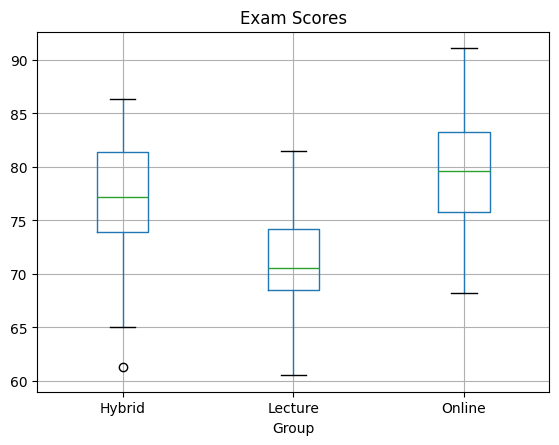

In [10]:
import matplotlib.pyplot as plt

df.boxplot(
    column="Score",
    by="Group"
)

plt.title("Exam Scores")
plt.suptitle("")
plt.show()

Post Hoc Testing

ANOVA says differences exist.

Which groups differ?

Use Tukey's HSD.

In [11]:
tukey = pairwise_tukeyhsd(
    df["Score"],
    df["Group"]
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
 Hybrid Lecture  -6.2062 0.0002 -9.6852 -2.7271   True
 Hybrid  Online   2.1957 0.2936 -1.2833  5.6748  False
Lecture  Online   8.4019    0.0  4.9229  11.881   True
------------------------------------------------------


Effect Size

Statistical significance

does NOT indicate practical importance.

Measure effect size.

For ANOVA

Eta Squared


	​

	​


In [16]:
eta_squared = (
    anova_table["sum_sq"][0] /
    anova_table["sum_sq"].sum()
)

print(eta_squared)

0.2908323646190229


/tmp/ipykernel_3400/2028621425.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  anova_table["sum_sq"][0] /


| η²  | Effect |
| --- | ------ |
| .01 | Small  |
| .06 | Medium |
| .14 | Large  |


Power Analysis in Python

In [13]:
from statsmodels.stats.power import (
    FTestAnovaPower
)

power = FTestAnovaPower()

Required Sample Size

Suppose

Effect size = 0.30

Power = .80

Alpha = .05

Three groups

In [14]:
sample_size = power.solve_power(
    effect_size=0.30,
    alpha=0.05,
    power=0.80,
    k_groups=3
)

print(sample_size)

110.10379136061924


Computing Power After Data Collection

Suppose

You collected

30 students per group

In [15]:
power_value = power.power(
    effect_size=0.30,
    nobs=90,
    alpha=0.05,
    k_groups=3
)

print(power_value)

0.7073313084279914


Interpretation

result is the chance of detecting the effect.

GROUP ACTIVITY 1

Take a dataset from kaggle and perform the following on three different variables

Tasks

Import all required Python libraries.

Create a Pandas DataFrame containing the scores and group labels.

Display the first five rows of the DataFrame.

Compute descriptive statistics for each teaching method.

Test the assumption of equal variances using Levene's Test.

Perform a one-way ANOVA using statsmodels.

Determine whether the teaching methods differ significantly.

Identify which programs differ significantly.

Create a boxplot of the three programs.

Write a one-sentence conclusion.

Discussion Questions

Why doesn't ANOVA tell us which groups differ?

Why is Tukey's HSD preferred over multiple t-tests?

Which relaxation program would you recommend based on the results?

GROUP ACTIVITY 2

Use Python to estimate sample size requirements and investigate how statistical power changes under different study designs.

Scenario

Your research team plans to compare four different exercise programs using a one-way ANOVA. Before collecting data, you must determine how many participants are needed.

Use the FTestAnovaPower class from statsmodels.stats.power.

Tasks

Part A – Required Sample Size

Find the required total sample size for each effect size below, assuming:

α = 0.05

Desired power = 0.80

Number of groups = 4

| Effect Size | Value |
| ----------- | ----: |
| Small       |  0.20 |
| Medium      |  0.35 |
| Large       |  0.50 |

Record the required sample size for each.

Part B – Comparing Power

Assume the true effect size is 0.35.

Calculate the statistical power for each total sample size below.

Total Sample Size

40

80

120

160

Create a table showing:

| Sample Size | Statistical Power |

Part C – Visualization

Create a line graph showing:

x-axis: Total sample size

y-axis: Statistical power

Discuss how increasing sample size affects power.